In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, root_mean_squared_error

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [44]:
base_path = r"C:\kdt_0900_osh\ml\resource\datasets"
file_name = r"titanic.csv"

file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)

### 타이타닉 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 설명 및 주요 값 예시 |
| :--- | :---: | :--- |
| **PassengerId** | `int64` | 승객 고유 번호 (1, 2, 3...) |
| **Survived** | `int64` | 생존 여부 (**0**: 사망 / **1**: 생존) |
| **Pclass** | `int64` | 객실 등급 (**1**: 1등석, **2**: 2등석, **3**: 3등석) |
| **Name** | `object` | 승객 이름 (호칭 포함: Mr, Mrs, Miss 등) |
| **Sex** | `object` | 성별 (`male`: 남성 / `female`: 여성) |
| **Age** | `float64` | 승객 나이 (결측치 존재) |
| **SibSp** | `int64` | 함께 탑승한 형제자매/배우자 수 (Siblings / Spouses) |
| **Parch** | `int64` | 함께 탑승한 부모/자녀 수 (Parents / Children) |
| **Ticket** | `object` | 티켓 번호 |
| **Fare** | `float64` | 탑승 요금 |
| **Cabin** | `object` | 객실 번호 (결측치 다수 존재) |
| **Embarked** | `object` | 탑승 항구 (**C**: Cherbourg, **Q**: Queenstown, **S**: Southampton) |

[문제 0] 프로젝트 목표 정의 (5점)

1. 데이터 수집·전처리부터 모델 학습, 성능 평가까지 이어지는 머신러닝 파이프라인의 전체 구조를 명확히 제시하세요.

2. 학습(Train) 및 평가(Test) 과정에서 발생할 수 있는 데이터 누수(Data Leakage)를 방지하기 위한 데이터 분리 및 처리 전략을 포함하여 기술하세요.

In [45]:
"""
    머신러닝 파이프라인의 구조는 크게 데이터 수집, 데이터 전처리, 데이터 스케일, 모델 준비, 모델 학습, 모델 예측, 모델 평가의 7단계로 나뉜다. 
    먼저 데이터를 수집하고, 전처리 과정을 거친다.
    전처리에는 이상치와 결측치의 대체 또는 제거, 인코딩, 
    데이터들의 특성에 맞게 표준화 또는 정규화를 거친다.
    이때 표준화와 정규화는 데이터의 분리 
"""
None

[문제 1] 데이터 확인 및 EDA (10점)

1. 데이터의 행/열 개수, 컬럼명, 결측치 개수(컬럼별) 요약을 작성하고, 이상치를 탐색 후 각 컬럼의 이상치로 판단하거나 이상치로 보지 않은 근거를 서술하세요(5점)

2. Survived 클래스 비율(생존/사망 비율)을 계산하고 해석하세요. (5점)

In [46]:
df.info()
# 데이터의 행은 891개, 열은 12개이며.
# 결측치가 존재하는 컬럼은 "Age", "Cabin", "Embarked"의 세 개 컬럼이다.

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [47]:
print(df["Age"].isna().sum())
print(df["Cabin"].isna().sum())
print(df["Embarked"].isna().sum())
# 결측치가 존재하는 각 컬럼의 결측치 개수는 
# "Age": 177개
# "Cabin": 687개
# "Embarked": 2개
# 이다.

177
687
2


In [48]:
df.describe()
# 이상치가 존재한다고 의심되는 컬럼은 "Age", "SibSp", "Parch", "Fare"이다.
# 네 가지 컬럼 모두 1,2,3분위 값 사이의 차이에 비해 최댓값이 지나치게 높음을 알 수 있다.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


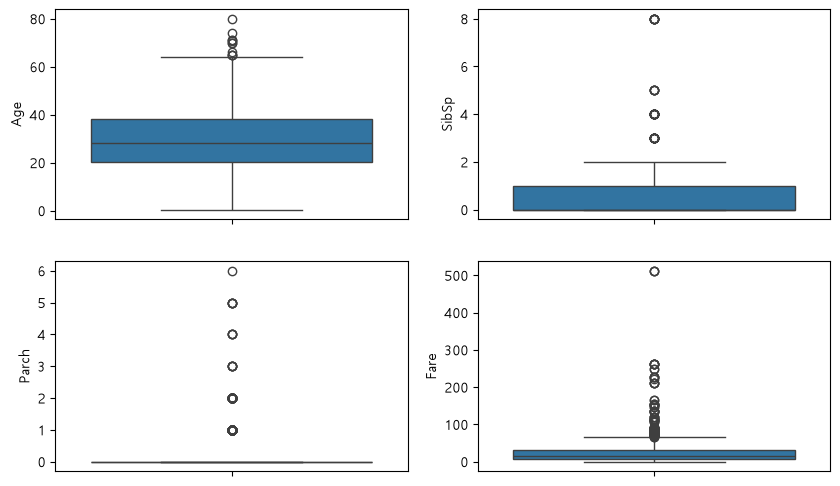

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [49]:
plt.figure(figsize=(10,6))
features = ["Age", "SibSp", "Parch", "Fare"]
for i, feature in enumerate(features, 1):
    plt.subplot(2,2,i)
    sns.boxplot(df, y=feature)

plt.show()
# Age 컬럼(탑승객의 나이)의 경우 0.42와 80의 두 가지 이상치로 의심되는 데이터가 존재하나, 80은 최대이상치값과 크게 차이나지 않으며 탑승객의 나이가 80세일 가능성이 충분하고, 0.42는 영아일 수 있기 때문에 이상치로 보지 않았다.
# SibSp, Parch 컬럼(가족인 동승자의 수)의 경우 동승자가 1 명 이상인 승객이 얼마 없기 때문에 최대이상치 너머의 값들이 존재하는 것으로 볼 수 있으며, 동승자의 수 또한 8명이나 6명이 될 수 있기에 이상치로 보지 않았다.
df[df["Fare"] == 512.329200]
# Fare 컬럼(탑승 요금)의 경우 값이 512인 데이터가 3개 존재하고, 3개 데이터의 Pclass(객실 등급), Ticket(티켓 번호), Embarked(탑승 항구)가 동일하고,
# PassengerId가 679인 승객의 객실 번호가 3개인 것으로 보아 
# 세 사람은 가족이 아닌 동승자이고, 모두 동일한 사람에게서 표를 구매한 것으로 추측되기에 이상치로 판단하지 않았다.

In [50]:
print(f"생존자 비율: 약 {(df["Survived"] == 1).mean() * 100:.0f}%"),
print(f"사망자 비율: 약 {(df["Survived"] == 0).mean() * 100:.0f}%")
# 사망자 비율

생존자 비율: 약 38%
사망자 비율: 약 62%


[문제 2] 다음 조건을 만족하도록 전처리를 설계하세요. (20점)

1. 수치형/범주형 변수를 구분하라. (5점)

2. 결측치 처리 전략을 각각 제시하세요. (예: age, embarked 등) (5점)

3. 범주형 인코딩 방법(원-핫 등)과 수치형 스케일링 필요 여부를 판단하고 근거를 서술하세요. (5점)

4. 스케일링을 표준화로 할지 정규화로 할지 판단 근거를 서술하세요. (5점)

In [51]:
# 수치형: Age, SibSp, Parch, Fare
# 분류형: Survived, Pclass, Sex, Embarked

In [52]:
# 먼저 Cabin 컬럼의 경우 결측치가 지나치게 많아 사용할 수 있는 데이터가 얼마 없을 뿐 아니라, Cabin 데이터를 학습시킬 경우 모델의 예측에 좋지 않은 영향을 미칠 수 있다 판단했다.
# 때문에 Cabin 컬럼 자체를 제거하는 것이 맞다.
# Age 컬럼은 수치형 데이터이므로 평균값, 중앙값 중 하나로 대체해야한다. 
# 이때 해당 컬럼에는 최대이상치를 초과하는 값들이 여럿 존재하므로 평균값보다는 중앙값으로 대체하는 것이 더 좋다.
# Embarked 컬럼은 분류형 데이터이므로 최빈값으로 대체해야한다.

In [59]:
df = df.drop("Cabin", axis=1)

In [60]:
age_median = df["Age"].dropna().median()
df["Age"] = df["Age"].fillna(age_median)

In [61]:
df["Age"].isna().sum()

np.int64(0)

In [66]:
embarked_mode = df["Embarked"].dropna().mode()
df["Embarked"] = df["Embarked"].fillna(embarked_mode[0])

In [67]:
df["Embarked"].isna().sum()

np.int64(0)

In [ ]:
# 이후 생존에 영향을 주지 않았을 것으로 판단되는 데이터를 제거.한다

In [74]:
titanic_df = df.drop(["PassengerId", "Name", "Ticket", "Embarked"], axis=1)
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000
887,1,1,female,19.0,0,0,30.0000
888,0,3,female,28.0,1,2,23.4500
889,1,1,male,26.0,0,0,30.0000


In [75]:
# 범주형 인코딩 방법은 Sex는 원 핫 인코딩, 나머지는 필요없음.
# Pclass를 제외한 다른 범주형 컬럼의 경우 두 가지로만 분류, Pclass는 3에서 1로 갈수록 좋아지는 거라서, Survived는 이미 숫자라서

In [76]:
titanic_df["Sex"] = titanic_df["Sex"].map({"male":0, "female":1})

In [77]:
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000
887,1,1,1,19.0,0,0,30.0000
888,0,3,1,28.0,1,2,23.4500
889,1,1,0,26.0,0,0,30.0000


In [78]:
# 수치형 컬럼의 스케일링은 필요하다. Age, SibSp, Parch, Fare 컬럼의 범위가 0~9 부터 100 단위까지 크게 차이나므로 범위를 맞춰줄 필요가 있다.

In [79]:
# 스케일링은 표준화가 적절하다. 표준화는 큰 값들을 상대적으로 더 작게, 작은 값들은 덜 작게 만들어 서로 다른 컬럼의 값들을 비슷한 범위 내의 수로 맞춰준다.
# 현재 수치형 컬럼들은 서로 작은 값과 큰 값의 차이가 매우 크기 때문에 정규화보다는 표준화가 더 적합하다.

[문제 3] 데이터 분리 및 검증 전략 (15점)

1. 학습/테스트 데이터를 분리하세요. (7점)

2. 분리 시 stratify(계층화) 적용 여부를 결정하고 이유를 설명하세요. (8점)

In [81]:
X = titanic_df.drop("Survived", axis=1)
X.head(1)

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,0,22.0,1,0,7.25


In [82]:
y = titanic_df["Survived"]
y.head(1)

0    0
Name: Survived, dtype: int64

In [84]:
# 계층화는 필요하다.
# 타겟 데이터인 Survived 컬럼의 데이터가 수치형이 아닌 범주형이므로 계층화를 통해 학습 데이터와 테스트 데이터에 골고루 분배되도록 해야한다.

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 6) (179, 6) (712,) (179,)


In [88]:
scaler = StandardScaler()

In [89]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

[문제 4] 모델 학습 (20점)

1. 기본 모델 1개 이상: (예: Logistic Regression, Lasso, Ridge, RandomForest 등) (5점)

2. 모델 학습 및 예측까지 이어지는 전체 흐름과 각 단계별 핵심 코드를 작성하세요. (10점)

3. 파라미터와 하이퍼파라미터의 차이를 서술하고, 하이퍼파라미터 튜닝을 “최소 1개 파라미터”만이라도 시도하세요.(5점)

In [105]:
lr = LogisticRegression(max_iter = 1000)

In [106]:
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [107]:
y_pred = lr.predict(X_test_scaled)

[문제 5] 평가 및 리포트 (20점)

1. Accuracy, Precision, Recall, F1 중 최소 2개 이상 사용하여 모델을 평가하세요. (10점)

2. Confusion Matrix 해석하세요. (5점)

3. 어떤 오류가 더 치명적인지(예: 생존자를 사망으로 예측 vs 반대) 상황을 가정해 서술하세요. (5점)

In [117]:
print(accuracy_score(y_test, y_pred))
print(lr.score(X_train_scaled, y_train))

0.7821229050279329
0.797752808988764


In [113]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[90, 20],
       [19, 50]])

In [119]:
Accuracy(정확도, 전체 값 중 모델이 올바르게 예측한 비율)는 약 78.2% 정도로, 정답률이 높지 않음을 알 수 있다.
Precision(정밀도, 모델이 양성으로 예측한 값 중 실제 양성인 값의 비율)은 약 71.4% 정도로, 정밀도 또한 높지 않다.
평가. 정확도가 80% 정도이므로 실용성은 있으나, 정확도가 그리 좋지는 않은 모델이다.

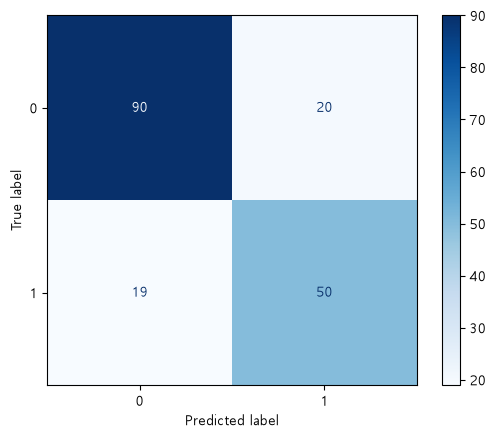

In [114]:
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.show()

In [120]:
# 실제 생존한 사람 중 모델이 생존했다고 예측한 값의 수: 50
# 실제 생존한 사람 중 모델이 사망했다고 예측한 값의 수: 19
# 실제 사망한 사람 중 모델이 생존했다고 예측한 값의 수: 20
# 실제 사망한 사람 중 모델이 사망했다고 예측한 값의 수: 90
# 생존자 예측보다 사망자 예측 정확도가 더 높음.
# 사망자 예측에 더 도움될 듯

In [ ]:
# 실제 생존자를 사망자로 예측했을 경우가 더 치명적이다.
# 이후 비슷한 사고가 발생하여 이 모델로 생존자를 예측했을 때, 그 사람이 실제로는 생존상태인데 사망했다고 예측할 경우 
# 생존해있을 것이라 예측되는 사람을 우선 구조해야하는 상황에서 사람들이 실제로는 생존해있음에도 불구하고 사망했다고 판단되어 구조하지 않는 상황이 발생할 수 있기 때문.

[문제 6] 최종 제출물 구성 (10점)

1. 데이터 요약(EDA 결과 핵심 3가지)하여 서술하세요. (3점)

2. 전처리 전략 요약(결측/인코딩/스케일링)하여 서술하세요. (3점)

3. 모델 선택 이유와 학습 설정(튜닝 포함)을 요약하여 서술하세요. (2점)

4. 최종 성능 지표 및 해석과 개선 아이디어 1개 이상 서술하세요. (2점)

In [ ]:
# 1) 